In [35]:
# ============================================
# Import Required Libraries
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

plt.style.use('ggplot')

In [52]:
import os

# Create images folder if it doesn't exist
os.makedirs("images", exist_ok=True)

# Customer Segmentation Analysis using K-Means Clustering

## Objective
The objective of this project is to segment customers based on their purchasing behaviour using RFM (Recency, Frequency, Monetary) analysis and K-Means clustering. These customer segments can help businesses implement targeted marketing strategies and improve customer retention.

In [36]:
# ============================================
# Load Dataset
# ============================================

df = pd.read_excel("online retail data.xlsx")

In [37]:
# ============================================
# Initial Data Inspection
# ============================================

print("First Five Rows")
display(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nDataset Information")
df.info()

print("\nMissing Values")
print(df.isnull().sum())

print("\nDescriptive Statistics")
display(df.describe())

First Five Rows


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



Dataset Shape
(541909, 8)

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB

Missing Values
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Descriptive Statistics


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


## Data Cleaning

The dataset is cleaned by:
- Removing missing Customer IDs.
- Excluding cancelled invoices.
- Removing transactions with negative quantities.
- Removing products with zero or negative prices.

In [38]:
# ============================================
# Data Cleaning
# ============================================

# Remove missing Customer IDs
df = df.dropna(subset=['CustomerID'])

# Remove cancelled invoices
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Remove invalid quantities
df = df[df['Quantity'] > 0]

# Remove invalid prices
df = df[df['UnitPrice'] > 0]

print("Dataset Shape After Cleaning:", df.shape)

Dataset Shape After Cleaning: (397884, 8)


In [39]:
# ============================================
# Feature Engineering
# ============================================

df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

display(df.head())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [40]:
# ============================================
# Create RFM Features
# ============================================

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

display(rfm.head())

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [41]:
# ============================================
# RFM Statistics
# ============================================

display(rfm.describe())

print("Average Purchase Value :", round(rfm['Monetary'].mean(),2))
print("Average Purchase Frequency :", round(rfm['Frequency'].mean(),2))
print("Average Customer Lifetime Value :", round(rfm['Monetary'].mean(),2))

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


Average Purchase Value : 2054.27
Average Purchase Frequency : 4.27
Average Customer Lifetime Value : 2054.27


In [42]:
# ============================================
# Data Standardization
# ============================================

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

## Elbow Method

The Elbow Method is used to determine the optimal number of customer clusters by analysing the Within-Cluster Sum of Squares (WCSS).

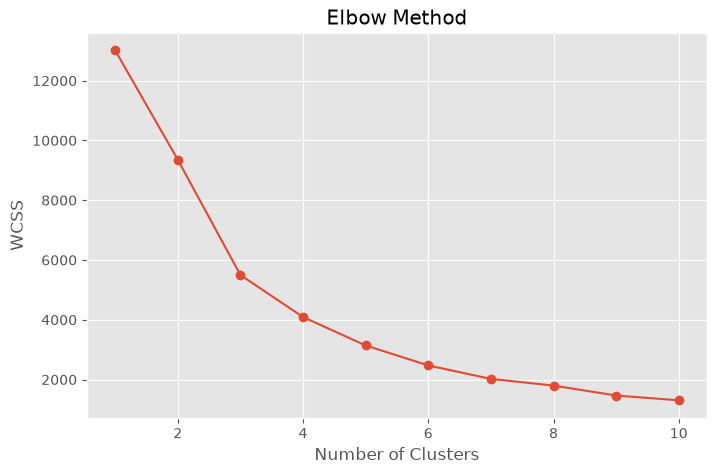

In [53]:
# ============================================
# Elbow Method
# ============================================

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)

    kmeans.fit(rfm_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.savefig("images/elbow_method.png", dpi=300, bbox_inches='tight')

plt.show()

### Observation

The curve begins to flatten around **K = 4**, indicating that four customer segments provide a good balance between model complexity and clustering performance.

In [44]:
# ============================================
# Build K-Means Model
# ============================================

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

display(rfm.head())

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64

<Figure size 700x500 with 0 Axes>

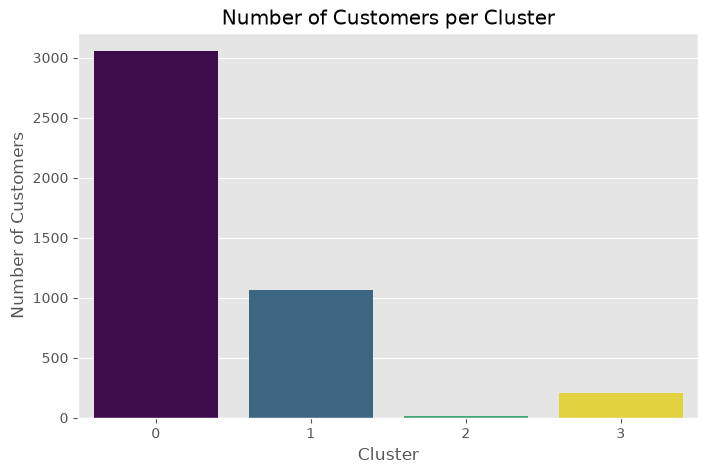

In [57]:
# ============================================
# Customers Per Cluster
# ============================================

cluster_counts = rfm['Cluster'].value_counts().sort_index()

display(cluster_counts)

plt.figure(figsize=(7,5))

plt.figure(figsize=(8,5))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values,
    hue=cluster_counts.index,
    palette='viridis',
    legend=False
)

plt.title("Number of Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.savefig("images/customer_count.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

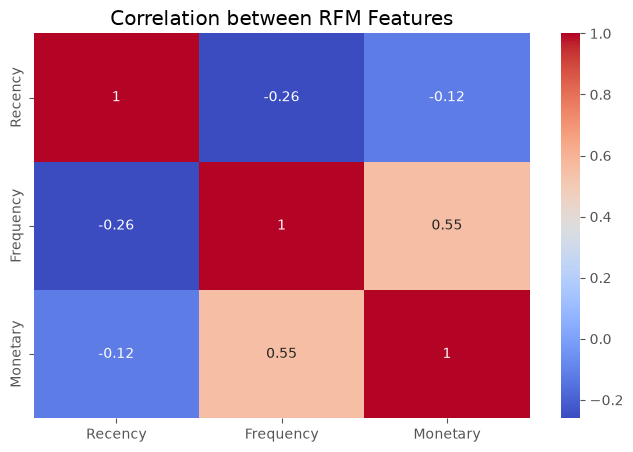

In [58]:
plt.figure(figsize=(8,5))

sns.heatmap(
    rfm[['Recency','Frequency','Monetary']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation between RFM Features")

plt.savefig("images/correlation_heatmap.png",
            dpi=300,
            bbox_inches='tight')

plt.show()

In [46]:
# ============================================
# Cluster Profile
# ============================================

cluster_profile = rfm.groupby('Cluster').agg({
    'Recency':'mean',
    'Frequency':'mean',
    'Monetary':'mean'
})

display(cluster_profile)

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1359.049284
1,248.075914,1.552015,480.617480
2,7.384615,82.538462,127338.313846
3,15.500000,22.333333,12709.090490


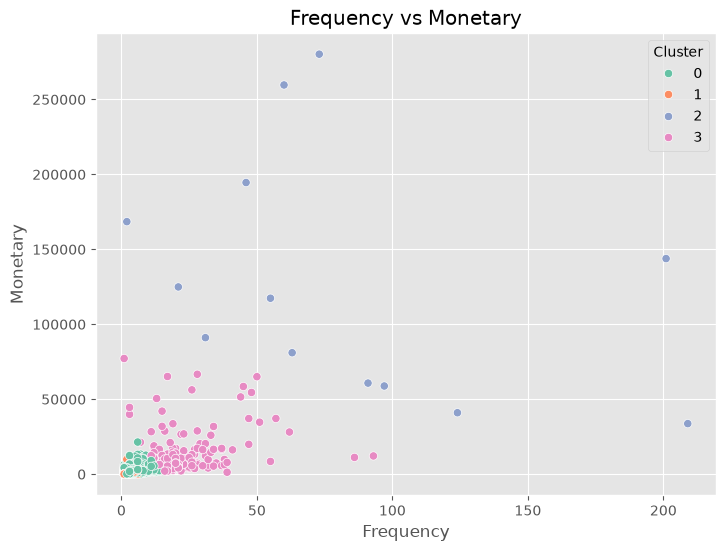

In [55]:
# ============================================
# Scatter Plot 1
# ============================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='Set2'
)

plt.title("Frequency vs Monetary")

plt.savefig("images/frequency_vs_monetary.png", dpi=300, bbox_inches='tight')

plt.show()

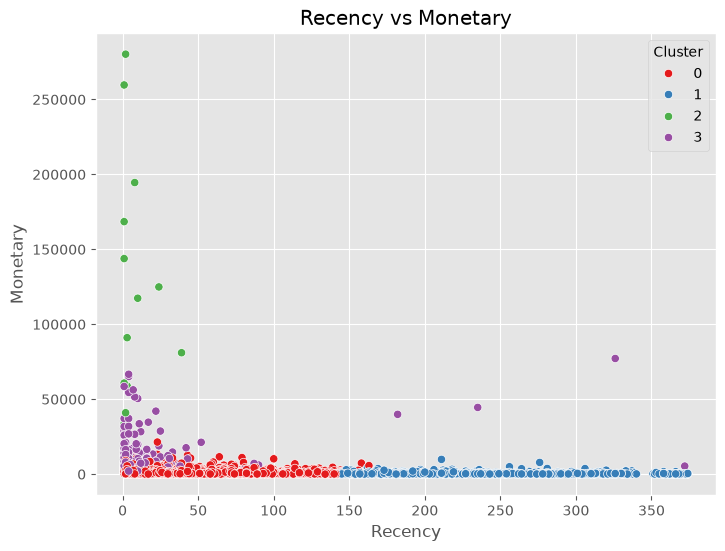

In [56]:
# ============================================
# Scatter Plot 2
# ============================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='Set1'
)

plt.title("Recency vs Monetary")

plt.savefig("images/recency_vs_monetary.png", dpi=300, bbox_inches='tight')

plt.show()

In [59]:
from sklearn.metrics import silhouette_score

score = silhouette_score(rfm_scaled,
                         rfm['Cluster'])

print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.616


# Conclusion

This project successfully segmented customers into four distinct groups using RFM analysis and the K-Means clustering algorithm.

Key findings include:

- High-value customers should be retained using loyalty programs.
- Moderate-value customers can be encouraged to spend more through personalized recommendations.
- Low-value customers respond well to promotional campaigns.
- Inactive customers require win-back strategies.

These insights enable businesses to improve customer retention, optimize marketing expenditure, and increase overall profitability.

In [60]:
# ============================================
# Export Results
# ============================================

rfm.to_csv("Customer_Segmentation_Output.csv", index_label="CustomerID")

print("Customer segmentation completed successfully!")
print("Output file saved as Customer_Segmentation_Output.csv")

Customer segmentation completed successfully!
Output file saved as Customer_Segmentation_Output.csv
